# Ejercicio 05 · Motor recomendador reproducible

Marlenis Judith Concepción Cuevas · INF-8239-C2 · Unidad III

Integra LAB08 (contenido) y LAB09 (factorización e hibridación) sobre el proyecto base `INF8239_U03_Recomendadores_Proyecto_Base`. MovieLens no se redistribuye: la primera celda lo descarga y verifica.

In [1]:
import json, subprocess, sys
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if not (ROOT / "data/raw/ml-latest-small/ratings.csv").exists():
    subprocess.run([sys.executable, str(ROOT / "scripts/download_data.py")], check=True)
from inf8239_u03.experiment import run
out = run()

## 1. Auditoría

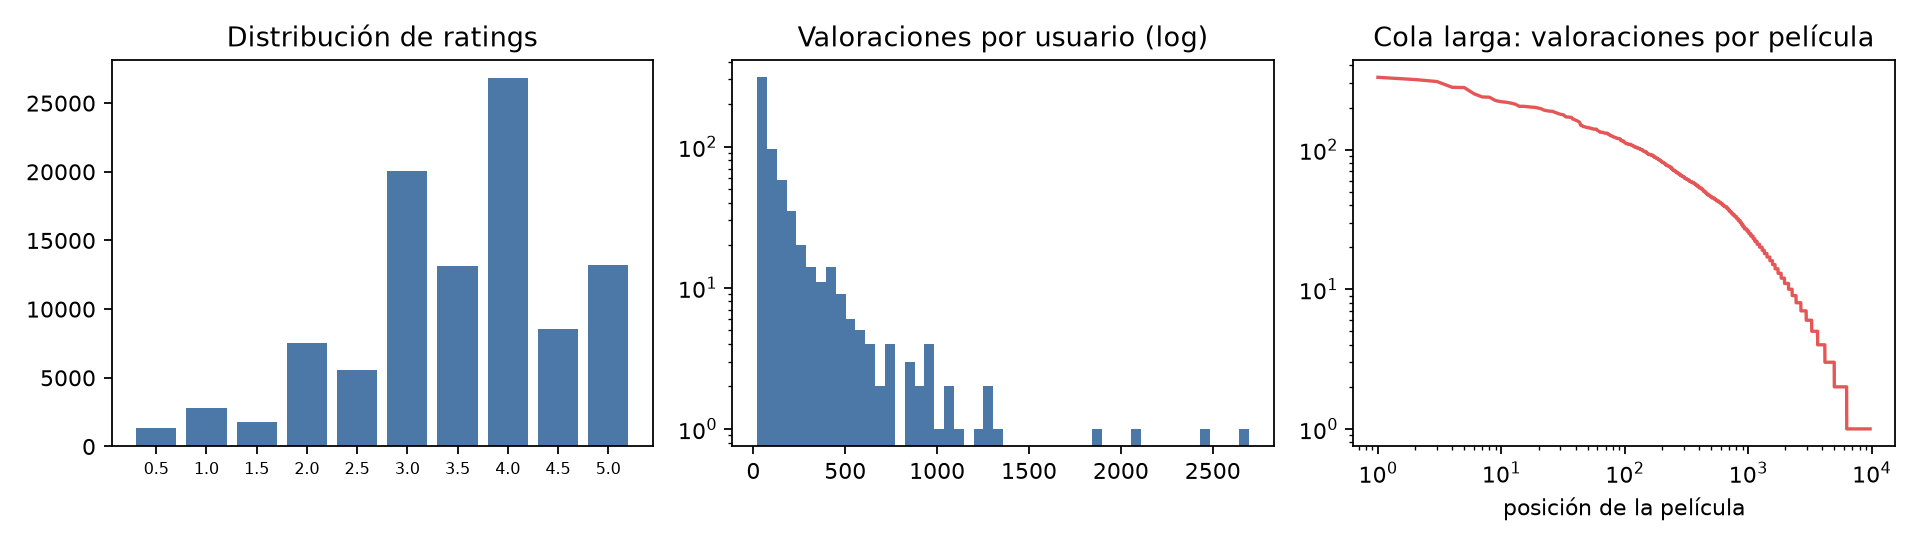

{'valoraciones': 100836,
 'usuarios': 610,
 'peliculas_catalogo': 9742,
 'peliculas_valoradas': 9724,
 'densidad': 0.017,
 'desde': '1996-03-29',
 'hasta': '2018-09-24',
 'duplicados_usuario_pelicula': 0,
 'nulos': 0,
 'valoraciones_por_usuario': {'min': 20, 'mediana': 70.5, 'max': 2698},
 'peliculas_con_una_valoracion': 3446,
 'porcentaje_valoraciones_en_top10pct_peliculas': 60.0,
 'peliculas_sin_genero': 34,
 'distribucion_rating': {'0.5': 1370,
  '1.0': 2811,
  '1.5': 1791,
  '2.0': 7551,
  '2.5': 5550,
  '3.0': 20047,
  '3.5': 13136,
  '4.0': 26818,
  '4.5': 8551,
  '5.0': 13211}}

In [2]:
display(Image(filename=str(ROOT / "reports/auditoria.png")))
out["audit"]

## 2. Particiones (corte temporal por usuario) y usuarios fríos

In [3]:
out['partition']

{'usuarios_frios': 61,
 'usuarios_calidos': 549,
 'train': 63101,
 'valid': 9023,
 'test': 18027,
 'regla': 'por usuario: 70 % más antiguo entrenamiento, 10 % siguiente validación, 20 % más reciente prueba'}

## 3. Validación: factorización, híbridos y Pareto

In [4]:
display(out["grid"].round(4))
out["valid"].round(4)

,factores,epocas,ndcg@10,rmse_valid,segundos
0,10,12,0.0497,0.9759,4.4211
1,20,12,0.0429,0.9612,4.6038
2,40,12,0.0427,0.9528,4.6441
3,20,30,0.0257,0.9119,11.4729


,modelo,usuarios,precision@10,recall@10,ndcg@10,hit@10,cobertura,novedad,pareto
0,popularidad,506,0.0279,0.0497,0.0425,0.2055,0.0067,2.1899,False
1,contenido,506,0.0053,0.0091,0.0093,0.0455,0.1036,6.3035,False
2,factorizacion,506,0.0300,0.0527,0.0497,0.2115,0.0715,2.6385,False
3,hibrido_a0.25,506,0.0097,0.0152,0.0164,0.0909,0.1681,5.7422,True
4,hibrido_a0.5,506,0.0215,0.0331,0.0363,0.1581,0.1422,4.1231,True
5,hibrido_a0.75,506,0.0334,0.0554,0.0527,0.2273,0.0978,3.0174,True


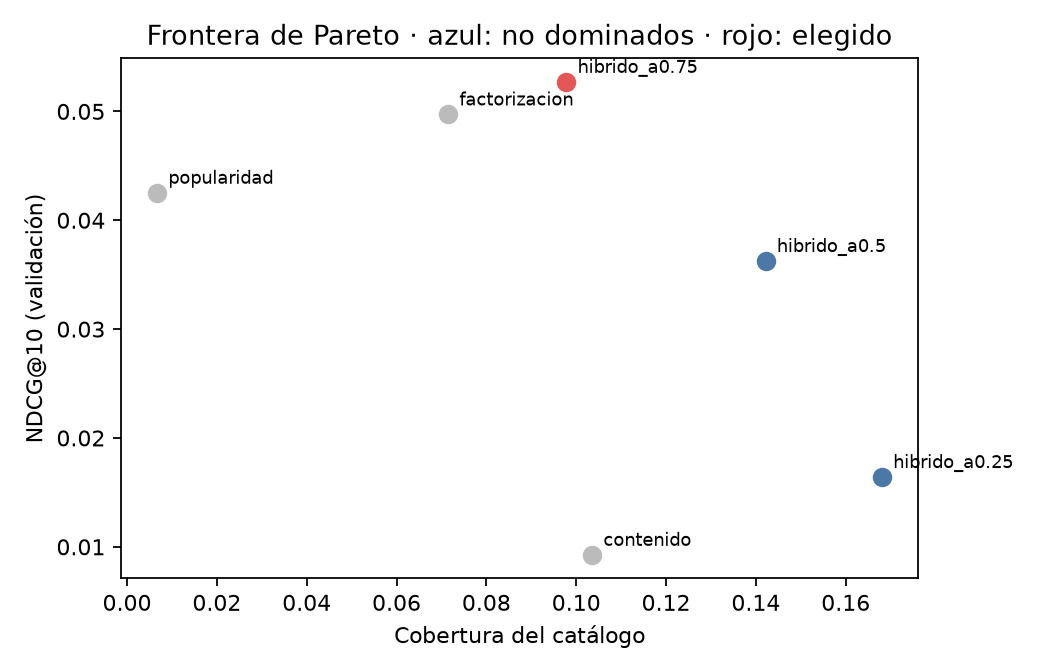

{'modelo_elegido': 'hibrido_a0.75',
 'factorizacion': {'factores': 10, 'epocas': 12},
 'razon': 'Frontera de Pareto: hibrido_a0.25, hibrido_a0.5, hibrido_a0.75. NDCG@10 máximo 0.0527; con al menos 95% de ese valor: hibrido_a0.75. Se elige el de mayor cobertura: hibrido_a0.75.',
 'regla': 'Pareto en validación (NDCG@10 y cobertura); mayor cobertura con NDCG >= 95% del máximo',
 'tomada_antes_de_test': True}

In [5]:
display(Image(filename=str(ROOT / "reports/pareto.png")))
out["decision"]

## 4. Prueba (una sola vez, tras la decisión)

In [6]:
print(json.dumps(out["extra"], indent=2))
out["test"].round(4)

{
  "rmse_test_factorizacion": 0.9938940015446637,
  "segundos_entrenar_factorizacion": 4.983677875003195,
  "fraccion_relevantes_alcanzables": 0.9330641213901126,
  "k": 10,
  "umbral_relevancia": 4.0
}


,modelo,usuarios,precision@10,recall@10,ndcg@10,hit@10,cobertura,novedad,segundos_recomendar
0,popularidad,533,0.0443,0.0352,0.0577,0.2739,0.0066,2.2862,0.7496
1,contenido,533,0.0090,0.0098,0.0107,0.0863,0.1011,6.1943,1.6249
2,factorizacion,533,0.0527,0.0401,0.0616,0.3077,0.0664,2.6947,0.8869
3,hibrido_a0.25,533,0.0178,0.0161,0.0249,0.1463,0.1518,5.5081,1.6922
4,hibrido_a0.5,533,0.0383,0.0276,0.0459,0.2570,0.1302,3.9773,1.6802
5,hibrido_a0.75,533,0.0484,0.0360,0.0587,0.2908,0.0894,3.0315,1.7372


## 5. Usuarios fríos

In [7]:
out['cold'].round(4)

,modelo,usuarios,precision@10,recall@10,ndcg@10,hit@10,cobertura,novedad
0,popularidad (0 valoraciones),61,0.2000,0.0376,0.2274,0.6721,0.0013,2.1624
1,contenido (5 valoraciones),61,0.0656,0.0077,0.0796,0.2951,0.0445,5.9747
2,popularidad sin repetir (5 valoraciones),61,0.2082,0.0384,0.2385,0.6885,0.0015,2.1588


## 6. Errores

In [8]:
display(out["by_activity"].round(4))
out["examples"]

,actividad,usuarios,historial_mediano,ndcg,hit,sin_aciertos
0,Q1 (menos activos),139,21.0,0.0198,0.1079,124
1,Q2,129,42.0,0.0557,0.2791,93
2,Q3,132,90.0,0.0528,0.2803,95
3,Q4 (más activos),133,288.0,0.1082,0.5038,66


,userId,historial,generos_que_le_gustan,generos_recomendados,generos_relevantes_en_test,relevantes_en_test
0,147,16,"Comedy, Drama, Action","Drama, Comedy, Crime","Adventure, Comedy, Sci-Fi",2
1,189,16,"Drama, Crime, Action","Crime, Drama, Action","Adventure, Action, Drama",2
2,194,16,"Comedy, Drama, War","Comedy, Drama, Action","Musical, Romance, Action",2
3,207,16,"Thriller, Adventure, Horror","Action, Adventure, Sci-Fi","Drama, Romance",1
4,278,16,"Drama, Comedy, Action","Drama, Comedy, Romance","Crime, Drama, Animation",4


## 7. Interpretación

| | |
|---|---|
| **Observación** | En prueba, la factorización obtiene NDCG@10 0.062, el híbrido α=0.75 0.059 y la popularidad 0.058; el contenido puro solo 0.011. El híbrido cubre el 8.9 % del catálogo frente al 6.6 % de la factorización y el 0.7 % de la popularidad. |
| **Evidencia** | En validación el híbrido fue el mejor en NDCG (0.053) y estuvo en la frontera de Pareto; la factorización quedó dominada. |
| **Interpretación** | La popularidad es un baseline difícil de superar en MovieLens. El híbrido cambia un 5 % de NDCG por un 35 % más de cobertura y más novedad. Los usuarios con poca historia (Q1) casi no reciben aciertos. |
| **Decisión** | Se mantiene el híbrido α=0.75 elegido en validación, con popularidad como fallback para usuarios nuevos: con 5 valoraciones iniciales el contenido no supera a la popularidad. |